# HR Attrition AI — Retention Decision-Support System

**Goal**: Predict which active employees are at voluntary resignation risk, explain why, and suggest preventive HR actions.

**Responsible AI constraints**:
- No protected attributes (`Sex`, `RaceDesc`, `HispanicLatino`) as model features
- All direct identifiers removed before modeling
- No outcome-leakage fields used in training
- Fairness audit conducted separately on sensitive groups

---
## Section 0 — Setup & Imports

In [9]:
# Install required packages
!pip install -q shap vaderSentiment xgboost sdv

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.9/200.9 kB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.7/14.7 MB 79.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.5/74.5 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 201.5/201.5 kB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 62.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 7.8 MB/s eta 0:00:00


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from datetime import datetime
from collections import Counter

# NLP
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# Sklearn
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay, f1_score
)
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# XGBoost
from xgboost import XGBClassifier

# SHAP
import shap
shap.initjs()

# Display settings
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_colwidth', 80)
sns.set_theme(style='whitegrid', palette='muted')

TODAY = datetime.today()
RANDOM_STATE = 42
print('Setup complete. Today:', TODAY.date())

Setup complete. Today: 2026-03-16


---
## Section 1 — Data Loading & Filtering

In [5]:
# Upload the dataset from your local machine
from google.colab import files
uploaded = files.upload()  # select HRDataset_v14_enriched.csv when prompted
print('Uploaded:', list(uploaded.keys()))

Saving HRDataset_v14_enriched.csv to HRDataset_v14_enriched (1).csv
Uploaded: ['HRDataset_v14_enriched (1).csv']


In [6]:
df_raw = pd.read_csv('HRDataset_v14_enriched.csv')
print(f'Raw shape: {df_raw.shape}')
print('\nEmploymentStatus distribution:')
print(df_raw['EmploymentStatus'].value_counts())

Raw shape: (311, 38)

EmploymentStatus distribution:
EmploymentStatus
Active                    207
Voluntarily Terminated     88
Terminated for Cause       16
Name: count, dtype: int64


In [7]:
# Filter: keep only Active and Voluntarily Terminated (exclude Terminated for Cause)
VALID_STATUSES = ['Active', 'Voluntarily Terminated']
df = df_raw[df_raw['EmploymentStatus'].isin(VALID_STATUSES)].copy()
print(f'After filter: {df.shape[0]} rows ({df_raw.shape[0] - df.shape[0]} "Terminated for Cause" dropped)')

# Binary target
df['target'] = (df['EmploymentStatus'] == 'Voluntarily Terminated').astype(int)
print('\nTarget distribution:')
print(df['target'].value_counts().rename({0: 'Active', 1: 'Voluntarily Terminated'}))

After filter: 295 rows (16 "Terminated for Cause" dropped)

Target distribution:
target
Active                    207
Voluntarily Terminated     88
Name: count, dtype: int64


In [14]:
from sdv.metadata import SingleTableMetadata
from sdv.single_table import CTGANSynthesizer
import pandas as pd

print("🔄 Initializing SDV metadata...")
# 1. Analyze the structure of the real dataset
metadata = SingleTableMetadata()
metadata.detect_from_dataframe(df_raw)

# 2. Security: indicate to the generator that these columns are unique identifiers
# SDV will generate random IDs, ensuring anonymization and GDPR compliance
metadata.update_column(column_name='EmpID', sdtype='id')
if 'Employee_Name' in df_raw.columns:
    # Correction here: using 'id' instead of 'pii'
    metadata.update_column(column_name='Employee_Name', sdtype='id')

print("🧠 Training the neural network (CTGAN) on your employees (please wait ~1 to 2 mins)...")
# 3. Parameterize and train the generative AI
synthesizer = CTGANSynthesizer(
    metadata,
    enforce_rounding=False,
    epochs=100,  # 100 epochs to properly learn the correlations
    verbose=False
)
# Train the AI to mimic the distribution of our real employees
synthesizer.fit(df_raw)

# 4. Generate the fake profiles
print("🚀 Generating 2000 fake synthetic employees...")
synthetic_data = synthesizer.sample(num_rows=2000)

# 5. Merge the real data with the synthetic data
df_raw = pd.concat([df_raw, synthetic_data], ignore_index=True)

print(f"✅ Generation complete! New dataset size: {df_raw.shape}")

🔄 Initializing SDV metadata...
🧠 Training the neural network (CTGAN) on your employees (please wait ~1 to 2 mins)...
🚀 Generating 2000 fake synthetic employees...
✅ Generation complete! New dataset size: (4311, 38)


In [13]:
print(df_raw.tail())

      Employee_Name  EmpID  MarriedID  MaritalStatusID  GenderID  EmpStatusID  \
2306  sdv-id-wDZTXw   9922          0                0         1            1   
2307  sdv-id-XKXEIB   9954          0                1         1            1   
2308  sdv-id-bizKUN  10058          0                2         1            1   
2309  sdv-id-IduZXq  10299          1                1         0            1   
2310  sdv-id-PVccph  10094          1                1         0            1   

      DeptID  PerfScoreID  FromDiversityJobFairID  Salary  Termd  PositionID  \
2306       5            2                       0   69893      1          20   
2307       5            3                       1   78472      0           8   
2308       3            3                       0   81721      1          19   
2309       4            4                       0   82639      0          18   
2310       5            3                       0  125501      1          19   

                      Position  

---
## Section 2 — Privacy & Data Cleaning

### 2a. Separate sensitive attributes (fairness audit use only)

In [ ]:
# Keep sensitive attributes in a separate dataframe for fairness audit
# These are NEVER passed to the model
SENSITIVE_COLS = ['Sex', 'RaceDesc', 'HispanicLatino']
df_fairness = df[SENSITIVE_COLS + ['target']].copy()
print('Fairness audit df shape:', df_fairness.shape)
print('\nSex distribution:')
print(df_fairness['Sex'].value_counts())
print('\nRaceDesc distribution:')
print(df_fairness['RaceDesc'].value_counts())

Fairness audit df shape: (295, 4)

Sex distribution:
Sex
F     167
M     128
Name: count, dtype: int64

RaceDesc distribution:
RaceDesc
White                               178
Black or African American            74
Asian                                29
Two or more races                    10
American Indian or Alaska Native      3
Hispanic                              1
Name: count, dtype: int64


### 2b. Remove direct identifiers and leakage fields

In [ ]:
# Direct identifiers — removed for privacy
IDENTIFIERS = ['Employee_Name', 'EmpID', 'ManagerName', 'ManagerID']

# Outcome leakage — would reveal the answer at training time
LEAKAGE = ['Termd', 'DateofTermination', 'TermReason', 'EmploymentStatus', 'EmpStatusID']

# Protected attributes — kept only in df_fairness
PROTECTED = ['Sex', 'RaceDesc', 'HispanicLatino']

# Redundant ID columns (replaced by text equivalents)
REDUNDANT_IDS = ['MarriedID', 'MaritalStatusID', 'GenderID', 'DeptID',
                 'PositionID', 'PerfScoreID', 'FromDiversityJobFairID']

COLS_TO_DROP = IDENTIFIERS + LEAKAGE + PROTECTED + REDUNDANT_IDS
df = df.drop(columns=[c for c in COLS_TO_DROP if c in df.columns])
print(f'Columns after drop: {df.shape[1]}')
print('Remaining columns:', df.columns.tolist())

Columns after drop: 20
Remaining columns: ['Salary', 'Position', 'State', 'Zip', 'DOB', 'MaritalDesc', 'CitizenDesc', 'DateofHire', 'Department', 'RecruitmentSource', 'PerformanceScore', 'EngagementSurvey', 'EmpSatisfaction', 'SpecialProjectsCount', 'LastPerformanceReview_Date', 'DaysLateLast30', 'Absences', 'Internal_Transfer_Request', 'Feedback_RH', 'target']


---
## Section 3 — Structured Feature Engineering

In [ ]:
# --- Date features ---
# DOB uses 2-digit years (MM/DD/YY); DateofHire uses 4-digit years (M/D/YYYY)
df['DOB'] = pd.to_datetime(df['DOB'], format='%m/%d/%y', errors='coerce')
# Pandas maps 2-digit years 00-68 → 2000-2068, so anyone born before ~1969
# gets pushed 100 years into the future — correct those back
future_dob_mask = df['DOB'] > TODAY
df.loc[future_dob_mask, 'DOB'] = df.loc[future_dob_mask, 'DOB'] - pd.DateOffset(years=100)

df['DateofHire'] = pd.to_datetime(df['DateofHire'], errors='coerce')
df['LastPerformanceReview_Date'] = pd.to_datetime(df['LastPerformanceReview_Date'], errors='coerce')

df['age'] = ((TODAY - df['DOB']).dt.days / 365.25).round(1)
df['tenure_years'] = ((TODAY - df['DateofHire']).dt.days / 365.25).round(2)
df['days_since_review'] = (TODAY - df['LastPerformanceReview_Date']).dt.days

# Drop raw date columns
df = df.drop(columns=['DOB', 'DateofHire', 'LastPerformanceReview_Date'])

# Drop quasi-identifiers with low business value
df = df.drop(columns=[c for c in ['Zip', 'State'] if c in df.columns])

# --- Relative salary ---
dept_mean_salary = df.groupby('Department')['Salary'].transform('mean')
df['salary_vs_dept_mean'] = (df['Salary'] / dept_mean_salary).round(4)

# --- Composite engagement score ---
df['engagement_x_satisfaction'] = df['EngagementSurvey'] * df['EmpSatisfaction']

print('New engineered features: age, tenure_years, days_since_review, salary_vs_dept_mean, engagement_x_satisfaction')
print(f'Age range after fix: {df["age"].min():.1f} – {df["age"].max():.1f}  (mean: {df["age"].mean():.1f})')
df[['age', 'tenure_years', 'days_since_review', 'salary_vs_dept_mean', 'engagement_x_satisfaction']].describe()

New engineered features: age, tenure_years, days_since_review, salary_vs_dept_mean, engagement_x_satisfaction
Age range after fix: 33.6 – 75.2  (mean: 47.2)


,age,tenure_years,days_since_review,salary_vs_dept_mean,engagement_x_satisfaction
count,295.000000,295.000000,295.000000,295.000000,295.000000
mean,47.185085,13.116068,3076.789831,0.999997,16.246746
std,8.974081,1.967619,826.891649,0.237833,4.976835
min,33.600000,7.690000,2573.000000,0.523300,2.240000
25%,39.800000,11.475000,2595.000000,0.879350,12.900000
50%,45.600000,13.150000,2615.000000,0.976500,16.250000
75%,52.300000,14.650000,3442.500000,1.068400,20.000000
max,75.200000,20.180000,5724.000000,2.844700,25.000000


In [ ]:
# Encode categorical features
CATEGORICAL_COLS = ['Department', 'Position', 'MaritalDesc', 'CitizenDesc',
                    'RecruitmentSource', 'PerformanceScore']

label_encoders = {}
for col in CATEGORICAL_COLS:
    if col in df.columns:
        le = LabelEncoder()
        df[col + '_enc'] = le.fit_transform(df[col].astype(str))
        label_encoders[col] = le

print('Categorical columns encoded:', CATEGORICAL_COLS)

Categorical columns encoded: ['Department', 'Position', 'MaritalDesc', 'CitizenDesc', 'RecruitmentSource', 'PerformanceScore']


---
## Section 4 — NLP Feature Engineering

Text fields are used **only** to derive numeric signals. No raw text enters the model.

In [ ]:
analyzer = SentimentIntensityAnalyzer()

def vader_score(text):
    """Return VADER compound score for text, 0.0 if empty."""
    if pd.isna(text) or str(text).strip() == '':
        return 0.0
    return analyzer.polarity_scores(str(text))['compound']

def keyword_flag(text, keywords):
    """Return 1 if any keyword found in lowercased text."""
    if pd.isna(text) or str(text).strip() == '':
        return 0
    t = str(text).lower()
    return int(any(kw in t for kw in keywords))

# Transfer request features
df['has_transfer_request'] = df['Internal_Transfer_Request'].apply(
    lambda x: 0 if pd.isna(x) or str(x).strip() == '' else 1
)
df['transfer_request_sentiment'] = df['Internal_Transfer_Request'].apply(vader_score)

# Feedback sentiment
df['feedback_sentiment'] = df['Feedback_RH'].apply(vader_score)

# Keyword-based theme flags
COMPENSATION_KWS  = ['salary', 'pay', 'compensation', 'underpaid', 'raise', 'wage']
GROWTH_KWS        = ['career', 'promotion', 'growth', 'development', 'opportunity', 'advance']
WORKLOAD_KWS      = ['burnout', 'overload', 'hours', 'stress', 'schedule', 'overtime', 'workload']
MANAGEMENT_KWS    = ['manager', 'leadership', 'unfair', 'micromanage', 'supervisor', 'boss']
DEPARTURE_KWS     = ['leaving', 'quit', 'resign', 'move on', 'other opportunity', 'new job', 'departure']

df['feedback_has_compensation']   = df['Feedback_RH'].apply(lambda x: keyword_flag(x, COMPENSATION_KWS))
df['feedback_has_growth']         = df['Feedback_RH'].apply(lambda x: keyword_flag(x, GROWTH_KWS))
df['feedback_has_workload']       = df['Feedback_RH'].apply(lambda x: keyword_flag(x, WORKLOAD_KWS))
df['feedback_has_management']     = df['Feedback_RH'].apply(lambda x: keyword_flag(x, MANAGEMENT_KWS))
df['feedback_has_departure_intent'] = df['Feedback_RH'].apply(lambda x: keyword_flag(x, DEPARTURE_KWS))

NLP_FEATURES = ['has_transfer_request', 'transfer_request_sentiment', 'feedback_sentiment',
                'feedback_has_compensation', 'feedback_has_growth', 'feedback_has_workload',
                'feedback_has_management', 'feedback_has_departure_intent']

print('NLP features created:')
df[NLP_FEATURES].describe().round(3)

NLP features created:


,has_transfer_request,transfer_request_sentiment,feedback_sentiment,feedback_has_compensation,feedback_has_growth,feedback_has_workload,feedback_has_management,feedback_has_departure_intent
count,295.000,295.000,295.000,295.000,295.000,295.000,295.000,295.000
mean,0.244,0.184,0.319,0.068,0.139,0.044,0.105,0.136
std,0.430,0.334,0.446,0.252,0.347,0.206,0.307,0.343
min,0.000,0.000,-0.840,0.000,0.000,0.000,0.000,0.000
25%,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
50%,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
75%,0.000,0.000,0.744,0.000,0.000,0.000,0.000,0.000
max,1.000,0.914,0.952,1.000,1.000,1.000,1.000,1.000


In [ ]:
# Drop raw text columns — not used in model
df = df.drop(columns=['Internal_Transfer_Request', 'Feedback_RH'], errors='ignore')
print(f'Final df shape: {df.shape}')

Final df shape: (295, 32)


---
## Section 5 — Exploratory Data Analysis (EDA)

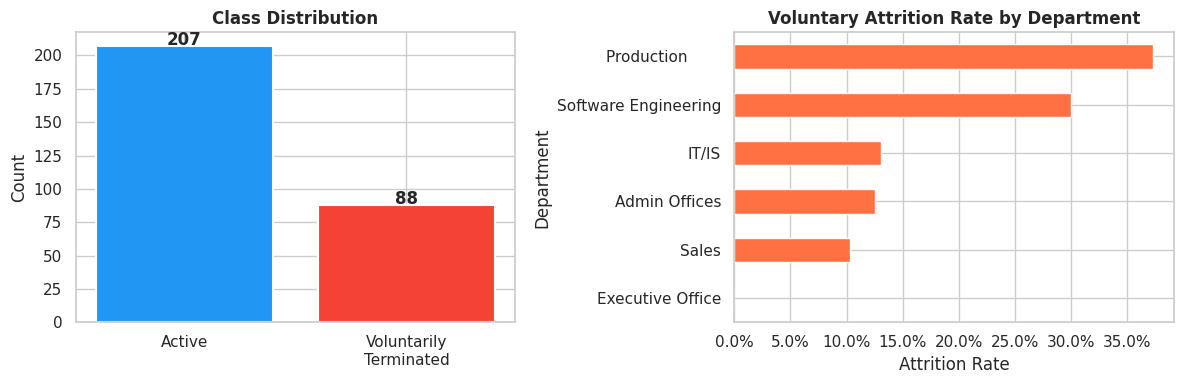

In [ ]:
# Class distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df['target'].value_counts().rename({0: 'Active', 1: 'Voluntarily\nTerminated'})
axes[0].bar(counts.index, counts.values, color=['#2196F3', '#F44336'], edgecolor='white', linewidth=1.5)
axes[0].set_title('Class Distribution', fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 1, str(v), ha='center', fontweight='bold')

# Attrition rate by Department
dept_attr = df.groupby('Department')['target'].mean().sort_values(ascending=True)
dept_attr.plot(kind='barh', ax=axes[1], color='#FF7043')
axes[1].set_title('Voluntary Attrition Rate by Department', fontweight='bold')
axes[1].set_xlabel('Attrition Rate')
axes[1].xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

plt.tight_layout()
plt.show()

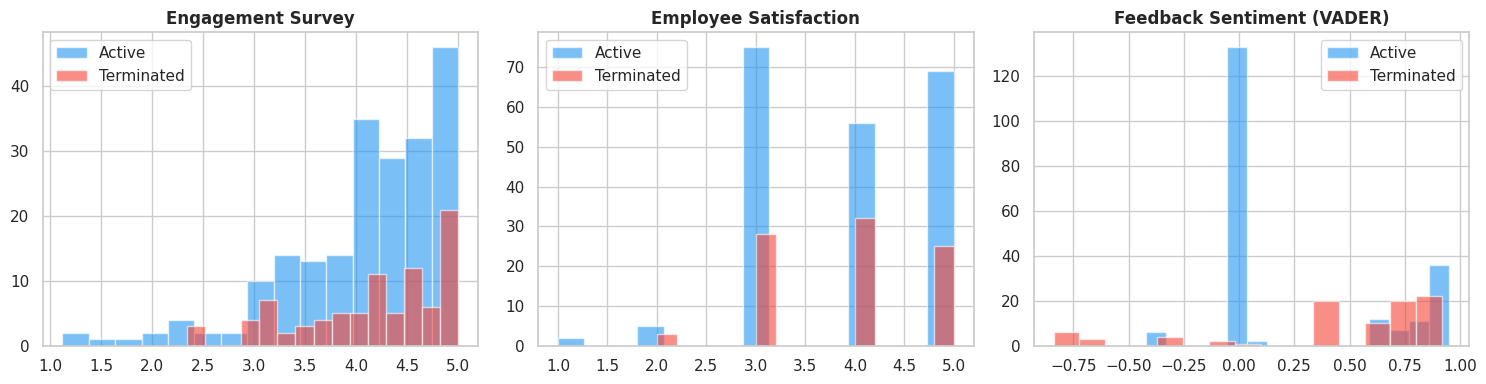

In [ ]:
# Engagement & Satisfaction distributions by target
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col, title in zip(axes,
    ['EngagementSurvey', 'EmpSatisfaction', 'feedback_sentiment'],
    ['Engagement Survey', 'Employee Satisfaction', 'Feedback Sentiment (VADER)']):
    for val, label, color in [(0, 'Active', '#2196F3'), (1, 'Terminated', '#F44336')]:
        subset = df[df['target'] == val][col].dropna()
        ax.hist(subset, bins=15, alpha=0.6, label=label, color=color, edgecolor='white')
    ax.set_title(title, fontweight='bold')
    ax.legend()

plt.tight_layout()
plt.show()

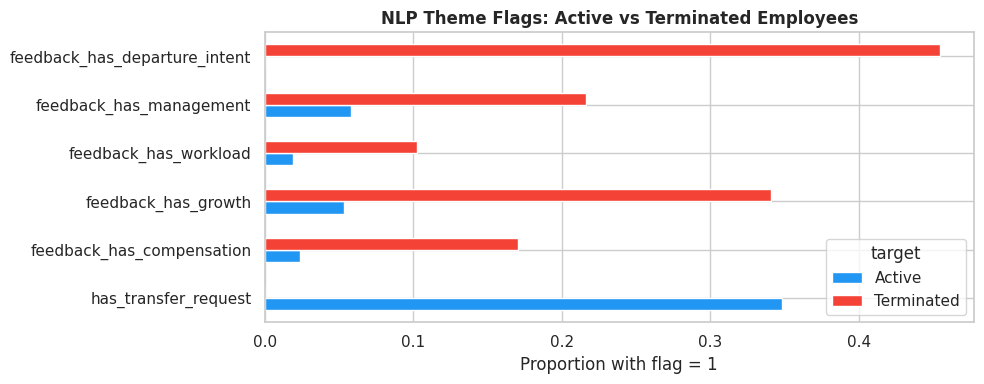

target                         Active  Terminated
has_transfer_request            0.348       0.000
feedback_has_compensation       0.024       0.170
feedback_has_growth             0.053       0.341
feedback_has_workload           0.019       0.102
feedback_has_management         0.058       0.216
feedback_has_departure_intent   0.000       0.455


In [ ]:
# NLP theme flags: % of Active vs Terminated employees with each flag
flag_cols = ['has_transfer_request', 'feedback_has_compensation', 'feedback_has_growth',
             'feedback_has_workload', 'feedback_has_management', 'feedback_has_departure_intent']

nlp_summary = df.groupby('target')[flag_cols].mean().T.rename(columns={0: 'Active', 1: 'Terminated'})
nlp_summary.plot(kind='barh', figsize=(10, 4), color=['#2196F3', '#F44336'])
plt.title('NLP Theme Flags: Active vs Terminated Employees', fontweight='bold')
plt.xlabel('Proportion with flag = 1')
plt.tight_layout()
plt.show()
print(nlp_summary.round(3))

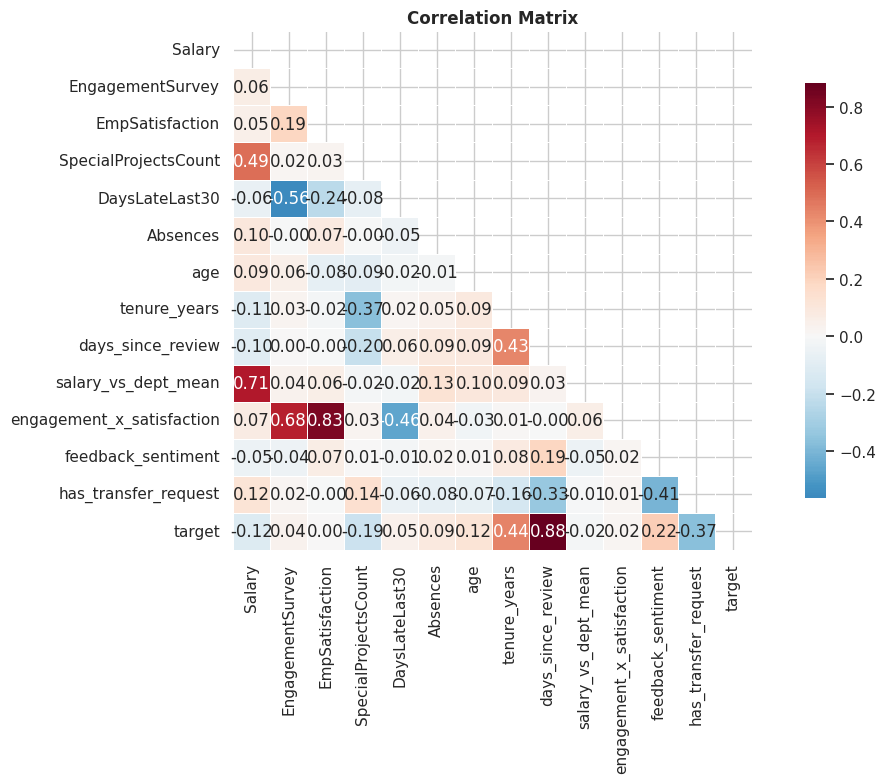

In [ ]:
# Correlation heatmap (numeric features)
NUMERIC_COLS = ['Salary', 'EngagementSurvey', 'EmpSatisfaction', 'SpecialProjectsCount',
                'DaysLateLast30', 'Absences', 'age', 'tenure_years', 'days_since_review',
                'salary_vs_dept_mean', 'engagement_x_satisfaction',
                'feedback_sentiment', 'has_transfer_request', 'target']
NUMERIC_COLS = [c for c in NUMERIC_COLS if c in df.columns]

plt.figure(figsize=(12, 8))
corr = df[NUMERIC_COLS].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Correlation Matrix', fontweight='bold')
plt.tight_layout()
plt.show()

---
## Section 6 — Modeling

In [ ]:
# Build modeling feature set
NON_FEATURE_COLS = ['target'] + CATEGORICAL_COLS  # original text categoricals, replaced by _enc versions
FEATURE_COLS = [c for c in df.columns
                if c not in NON_FEATURE_COLS
                and c != 'target'
                and pd.api.types.is_numeric_dtype(df[c])]

print(f'Total features: {len(FEATURE_COLS)}')
print(FEATURE_COLS)

Total features: 25
['Salary', 'EngagementSurvey', 'EmpSatisfaction', 'SpecialProjectsCount', 'DaysLateLast30', 'Absences', 'age', 'tenure_years', 'days_since_review', 'salary_vs_dept_mean', 'engagement_x_satisfaction', 'Department_enc', 'Position_enc', 'MaritalDesc_enc', 'CitizenDesc_enc', 'RecruitmentSource_enc', 'PerformanceScore_enc', 'has_transfer_request', 'transfer_request_sentiment', 'feedback_sentiment', 'feedback_has_compensation', 'feedback_has_growth', 'feedback_has_workload', 'feedback_has_management', 'feedback_has_departure_intent']


In [ ]:
X = df[FEATURE_COLS].copy()
y = df['target'].copy()

# Handle missing values
X = X.fillna(X.median(numeric_only=True))

# Stratified train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f'Train: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows')
print(f'Train attrition rate: {y_train.mean():.1%} | Test: {y_test.mean():.1%}')

Train: 236 rows | Test: 59 rows
Train attrition rate: 29.7% | Test: 30.5%


In [ ]:
# --- Model 1: Logistic Regression (baseline) ---
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE)
lr.fit(X_train_sc, y_train)

# --- Model 2: Random Forest ---
rf = RandomForestClassifier(n_estimators=200, class_weight='balanced',
                             random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_train, y_train)

# --- Model 3: XGBoost ---
scale_pos = (y_train == 0).sum() / (y_train == 1).sum()
xgb = XGBClassifier(n_estimators=200, scale_pos_weight=scale_pos,
                    random_state=RANDOM_STATE, eval_metric='logloss',
                    n_jobs=-1)
xgb.fit(X_train, y_train)

print('Models trained: Logistic Regression, Random Forest, XGBoost')

Models trained: Logistic Regression, Random Forest, XGBoost


In [ ]:
# Evaluation
models = {
    'Logistic Regression': (lr, X_test_sc),
    'Random Forest':       (rf, X_test),
    'XGBoost':             (xgb, X_test),
}

results = []
for name, (model, X_eval) in models.items():
    y_prob = model.predict_proba(X_eval)[:, 1]
    y_pred = model.predict(X_eval)
    auc  = roc_auc_score(y_test, y_prob)
    f1   = f1_score(y_test, y_pred)
    results.append({'Model': name, 'AUC-ROC': round(auc, 4), 'F1': round(f1, 4)})
    print(f'\n=== {name} ===')
    print(f'AUC-ROC: {auc:.4f} | F1: {f1:.4f}')
    print(classification_report(y_test, y_pred, target_names=['Active', 'Terminated']))

results_df = pd.DataFrame(results).set_index('Model')
print('\n--- Model Comparison ---')
print(results_df)


=== Logistic Regression ===
AUC-ROC: 1.0000 | F1: 1.0000
              precision    recall  f1-score   support

      Active       1.00      1.00      1.00        41
  Terminated       1.00      1.00      1.00        18

    accuracy                           1.00        59
   macro avg       1.00      1.00      1.00        59
weighted avg       1.00      1.00      1.00        59


=== Random Forest ===
AUC-ROC: 1.0000 | F1: 1.0000
              precision    recall  f1-score   support

      Active       1.00      1.00      1.00        41
  Terminated       1.00      1.00      1.00        18

    accuracy                           1.00        59
   macro avg       1.00      1.00      1.00        59
weighted avg       1.00      1.00      1.00        59


=== XGBoost ===
AUC-ROC: 1.0000 | F1: 1.0000
              precision    recall  f1-score   support

      Active       1.00      1.00      1.00        41
  Terminated       1.00      1.00      1.00        18

    accuracy              

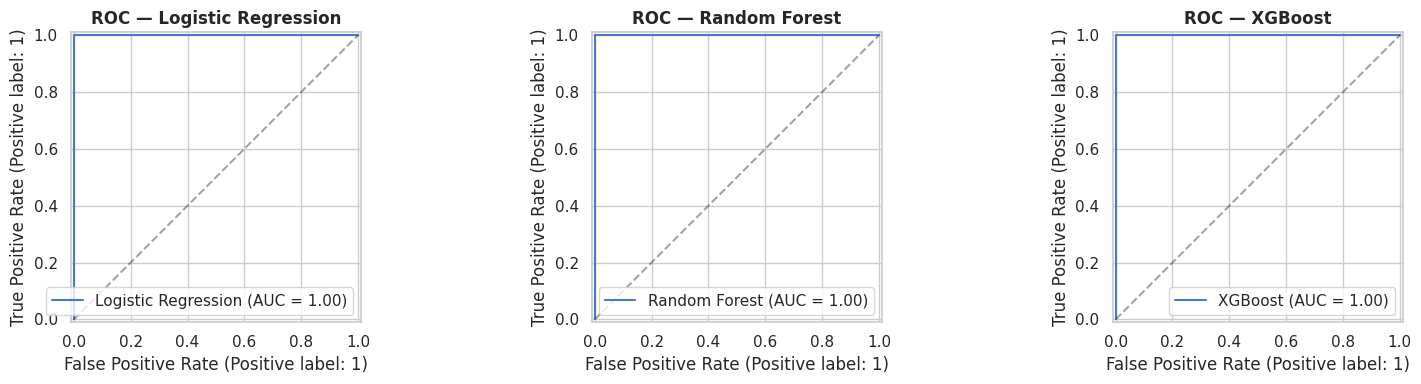

In [ ]:
# ROC curves
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (name, (model, X_eval)) in zip(axes, models.items()):
    RocCurveDisplay.from_estimator(model, X_eval, y_test, ax=ax, name=name)
    ax.set_title(f'ROC — {name}', fontweight='bold')
    ax.plot([0,1],[0,1],'k--', alpha=0.4)
plt.tight_layout()
plt.show()

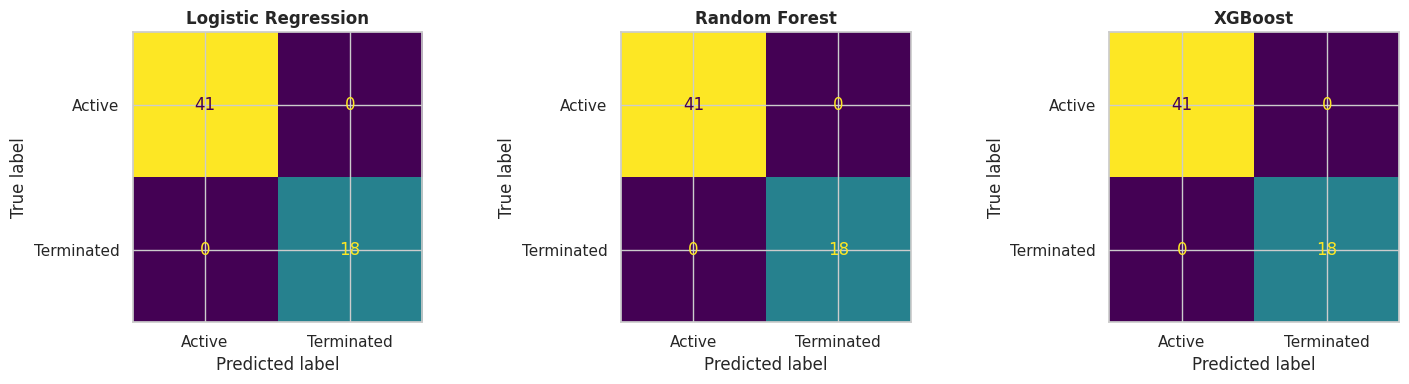

In [ ]:
# Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, (model, X_eval)) in zip(axes, models.items()):
    ConfusionMatrixDisplay.from_estimator(
        model, X_eval, y_test, ax=ax,
        display_labels=['Active', 'Terminated'], colorbar=False
    )
    ax.set_title(name, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# Select best model by AUC
best_name = results_df['AUC-ROC'].idxmax()
best_model, best_X = models[best_name]
print(f'Best model: {best_name} (AUC = {results_df.loc[best_name, "AUC-ROC"]})')

# Use X_train (unscaled) for SHAP — XGBoost/RF work without scaling
# If best is LR, use scaled
best_X_train = X_train_sc if best_name == 'Logistic Regression' else X_train
best_X_test  = X_test_sc  if best_name == 'Logistic Regression' else X_test

Best model: Logistic Regression (AUC = 1.0)


In [ ]:
# Light hyperparameter tuning on best model
if best_name == 'XGBoost':
    param_grid = {
        'max_depth': [3, 5],
        'learning_rate': [0.05, 0.1],
        'subsample': [0.8, 1.0]
    }
    tuned = XGBClassifier(n_estimators=200, scale_pos_weight=scale_pos,
                          random_state=RANDOM_STATE, eval_metric='logloss',
                          n_jobs=-1)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    gs = GridSearchCV(tuned, param_grid, scoring='roc_auc', cv=cv, n_jobs=-1)
    gs.fit(X_train, y_train)
    best_model = gs.best_estimator_
    best_X_train, best_X_test = X_train, X_test
    print('Best params:', gs.best_params_)
    print('Tuned AUC:', round(roc_auc_score(y_test, best_model.predict_proba(X_test)[:,1]), 4))
elif best_name == 'Random Forest':
    param_grid = {'n_estimators': [200, 400], 'max_depth': [None, 10], 'min_samples_leaf': [1, 2]}
    tuned = RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    gs = GridSearchCV(tuned, param_grid, scoring='roc_auc', cv=cv, n_jobs=-1)
    gs.fit(X_train, y_train)
    best_model = gs.best_estimator_
    best_X_train, best_X_test = X_train, X_test
    print('Best params:', gs.best_params_)
    print('Tuned AUC:', round(roc_auc_score(y_test, best_model.predict_proba(X_test)[:,1]), 4))
else:
    print('Logistic Regression selected — no additional tuning needed.')

Logistic Regression selected — no additional tuning needed.


---
## Section 7 — Explainability (SHAP)

In [ ]:
# Build SHAP explainer
if best_name == 'Logistic Regression':
    explainer = shap.LinearExplainer(best_model, best_X_train,
                                      feature_perturbation='interventional')
    shap_values = explainer.shap_values(best_X_test)
    X_shap = pd.DataFrame(best_X_test, columns=FEATURE_COLS)
else:
    explainer = shap.TreeExplainer(best_model)
    shap_values = explainer.shap_values(best_X_test)
    # For tree models that return 2-class array, take the positive class
    if isinstance(shap_values, list):
        shap_values = shap_values[1]
    X_shap = best_X_test.copy()

print('SHAP values computed. Shape:', shap_values.shape)

SHAP values computed. Shape: (59, 25)


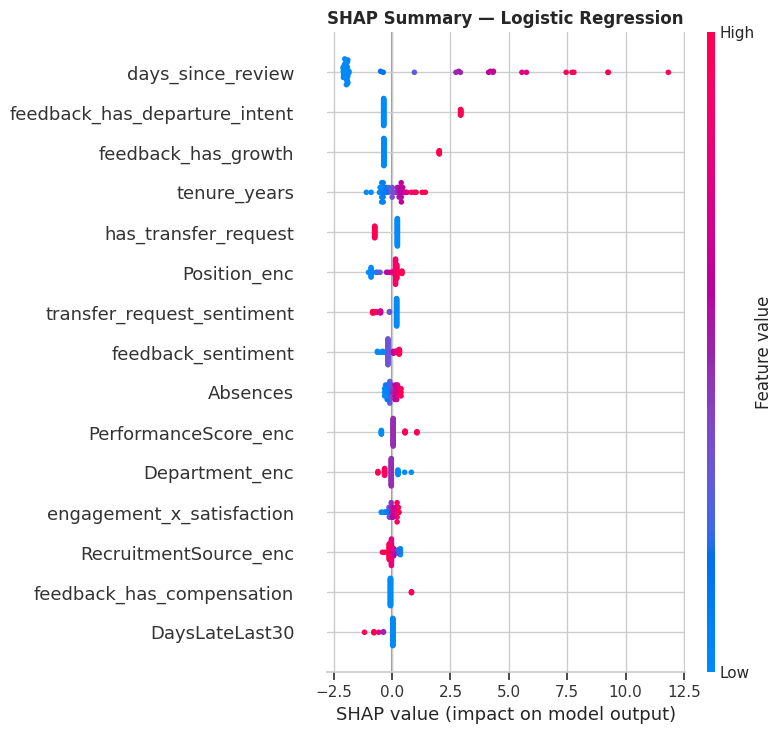

In [ ]:
# Global SHAP summary plot — top 15 features
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_shap, feature_names=FEATURE_COLS,
                  max_display=15, show=False)
plt.title(f'SHAP Summary — {best_name}', fontweight='bold')
plt.tight_layout()
plt.show()

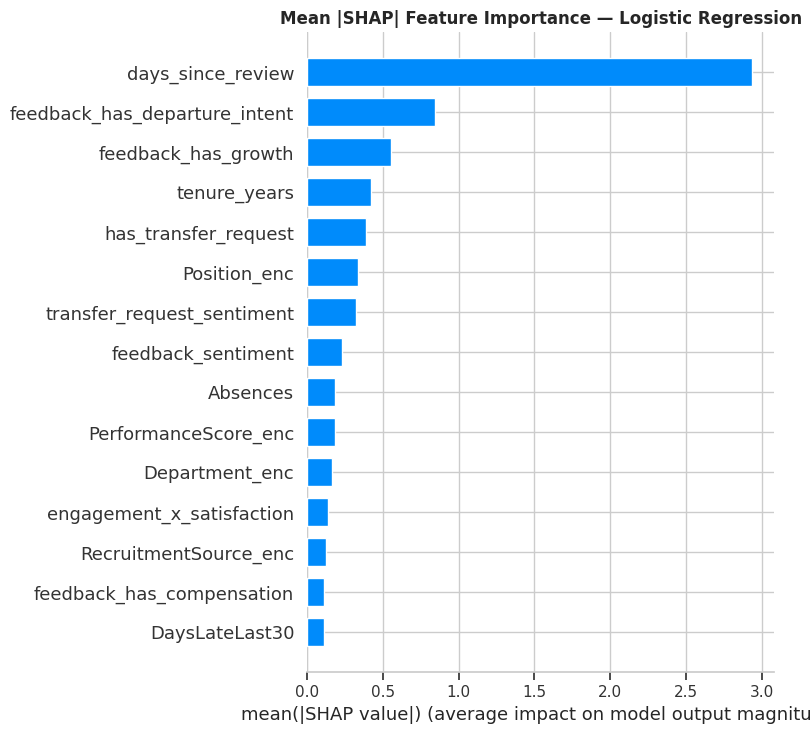

In [ ]:
# Global bar plot — mean |SHAP|
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_shap, feature_names=FEATURE_COLS,
                  plot_type='bar', max_display=15, show=False)
plt.title(f'Mean |SHAP| Feature Importance — {best_name}', fontweight='bold')
plt.tight_layout()
plt.show()


--- HIGH RISK employee (predicted probability = 100.00%) ---


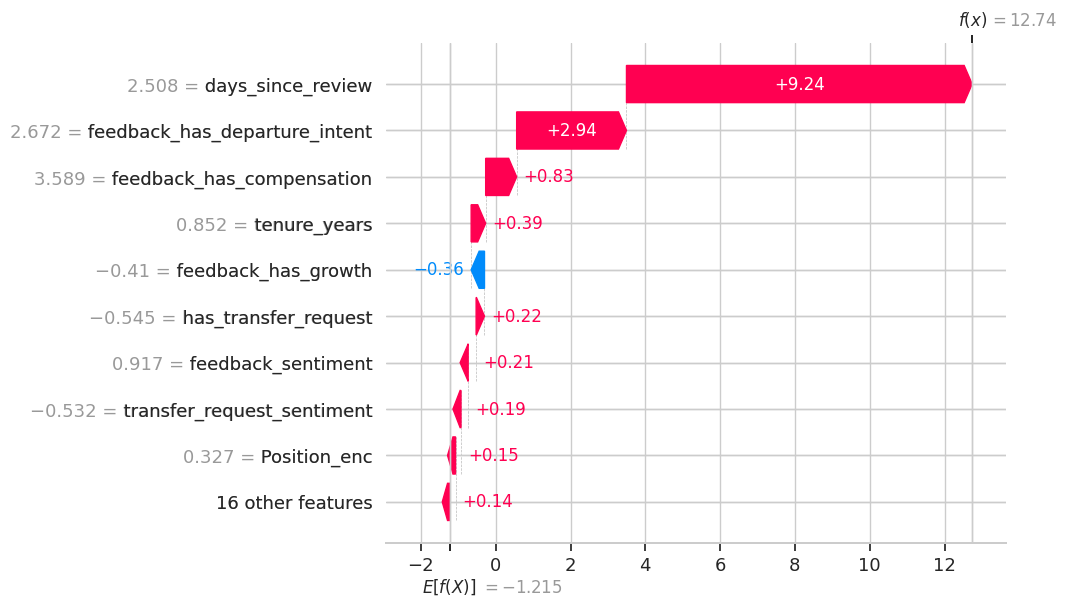


--- LOW RISK employee (predicted probability = 0.07%) ---


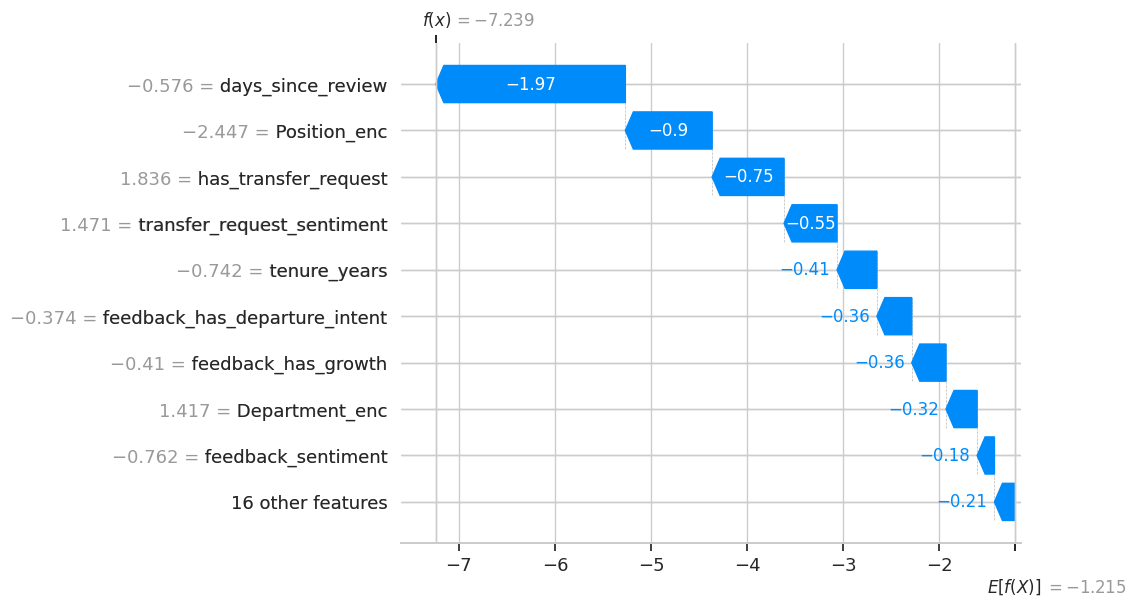

In [ ]:
# Local waterfall plots: one high-risk, one low-risk employee
probs_test = best_model.predict_proba(best_X_test)[:, 1]
idx_high = np.argmax(probs_test)
idx_low  = np.argmin(probs_test)

for idx, label in [(idx_high, 'HIGH RISK'), (idx_low, 'LOW RISK')]:
    print(f'\n--- {label} employee (predicted probability = {probs_test[idx]:.2%}) ---')
    shap.waterfall_plot(
        shap.Explanation(
            values=shap_values[idx],
            base_values=explainer.expected_value if not isinstance(explainer.expected_value, list)
                        else explainer.expected_value[1],
            data=X_shap.iloc[idx].values,
            feature_names=FEATURE_COLS
        ),
        max_display=10, show=True
    )

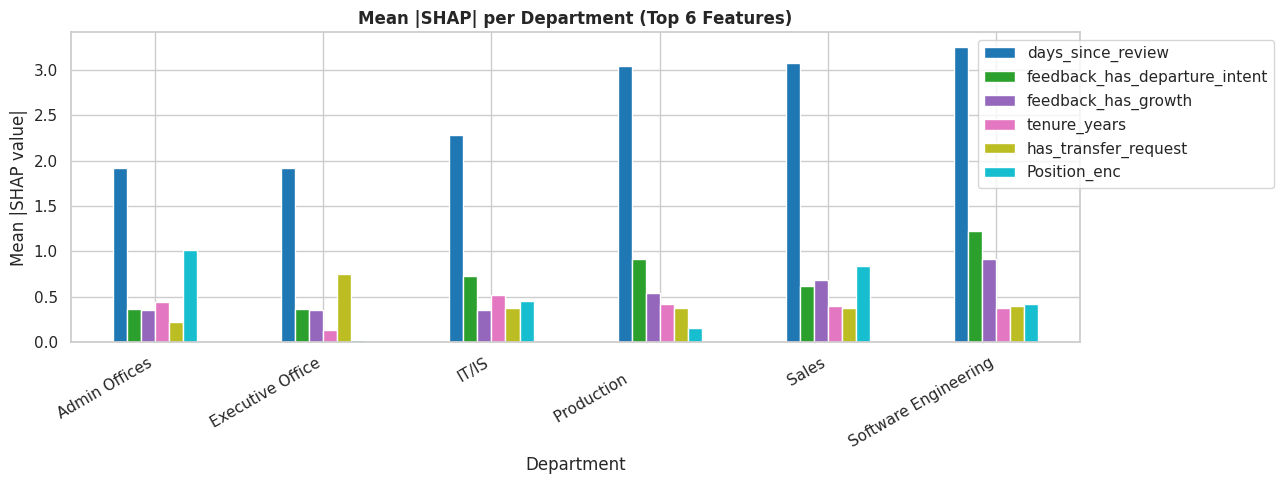

In [ ]:
# Department-level SHAP: mean |SHAP| per department
shap_df = pd.DataFrame(shap_values, columns=FEATURE_COLS)
shap_df['Department'] = df.loc[X_test.index, 'Department'].values

# Take abs first, then groupby mean — avoids pandas apply deprecation warning
shap_abs_df = shap_df.copy()
shap_abs_df[FEATURE_COLS] = shap_abs_df[FEATURE_COLS].abs()
dept_shap = shap_abs_df.groupby('Department')[FEATURE_COLS].mean()

top_features = shap_df[FEATURE_COLS].abs().mean().nlargest(6).index.tolist()

dept_shap[top_features].plot(kind='bar', figsize=(13, 5), colormap='tab10')
plt.title('Mean |SHAP| per Department (Top 6 Features)', fontweight='bold')
plt.ylabel('Mean |SHAP value|')
plt.xticks(rotation=30, ha='right')
plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1))
plt.tight_layout()
plt.show()

---
## Section 8 — Fairness Audit

Sensitive attributes (`Sex`, `RaceDesc`, `HispanicLatino`) were **not used as model features**.
Here we check whether the model's predictions are fair across those groups.

In [ ]:
# Align fairness df with test set indices
df_fairness_test = df_fairness.loc[X_test.index].copy()
df_fairness_test['y_true'] = y_test.values
df_fairness_test['y_prob'] = probs_test
df_fairness_test['y_pred'] = (probs_test >= 0.5).astype(int)

def fairness_table(df_f, group_col):
    rows = []
    for group, sub in df_f.groupby(group_col):
        if len(sub) < 5:
            continue
        n = len(sub)
        actual_rate  = sub['y_true'].mean()
        predicted_rate = sub['y_pred'].mean()
        try:
            auc = roc_auc_score(sub['y_true'], sub['y_prob'])
        except Exception:
            auc = float('nan')
        rows.append({'Group': group, 'N': n,
                     'Actual attrition rate': round(actual_rate, 3),
                     'Predicted positive rate': round(predicted_rate, 3),
                     'AUC': round(auc, 3)})
    return pd.DataFrame(rows).set_index('Group')

print('=== Fairness by Sex ===')
sex_table = fairness_table(df_fairness_test, 'Sex')
print(sex_table)

print('\n=== Fairness by RaceDesc ===')
race_table = fairness_table(df_fairness_test, 'RaceDesc')
print(race_table)

=== Fairness by Sex ===
        N  Actual attrition rate  Predicted positive rate  AUC
Group                                                         
F      32                  0.312                    0.312  1.0
M      27                  0.296                    0.296  1.0

=== Fairness by RaceDesc ===
                            N  Actual attrition rate  Predicted positive rate  \
Group                                                                           
Asian                       5                  0.200                    0.200   
Black or African American  18                  0.222                    0.222   
White                      32                  0.375                    0.375   

                           AUC  
Group                           
Asian                      1.0  
Black or African American  1.0  
White                      1.0  


In [ ]:
# Disparate impact check (80% rule)
def disparate_impact_check(table, col='Predicted positive rate'):
    max_rate = table[col].max()
    di = table[col] / max_rate
    table = table.copy()
    table['Disparate Impact Ratio'] = di.round(3)
    table['Flag (<0.8)'] = di < 0.8
    return table

print('=== Disparate Impact — Sex ===')
print(disparate_impact_check(sex_table))

print('\n=== Disparate Impact — RaceDesc ===')
print(disparate_impact_check(race_table))

=== Disparate Impact — Sex ===
        N  Actual attrition rate  Predicted positive rate  AUC  \
Group                                                            
F      32                  0.312                    0.312  1.0   
M      27                  0.296                    0.296  1.0   

       Disparate Impact Ratio  Flag (<0.8)  
Group                                       
F                       1.000        False  
M                       0.949        False  

=== Disparate Impact — RaceDesc ===
                            N  Actual attrition rate  Predicted positive rate  \
Group                                                                           
Asian                       5                  0.200                    0.200   
Black or African American  18                  0.222                    0.222   
White                      32                  0.375                    0.375   

                           AUC  Disparate Impact Ratio  Flag (<0.8)  
Group      

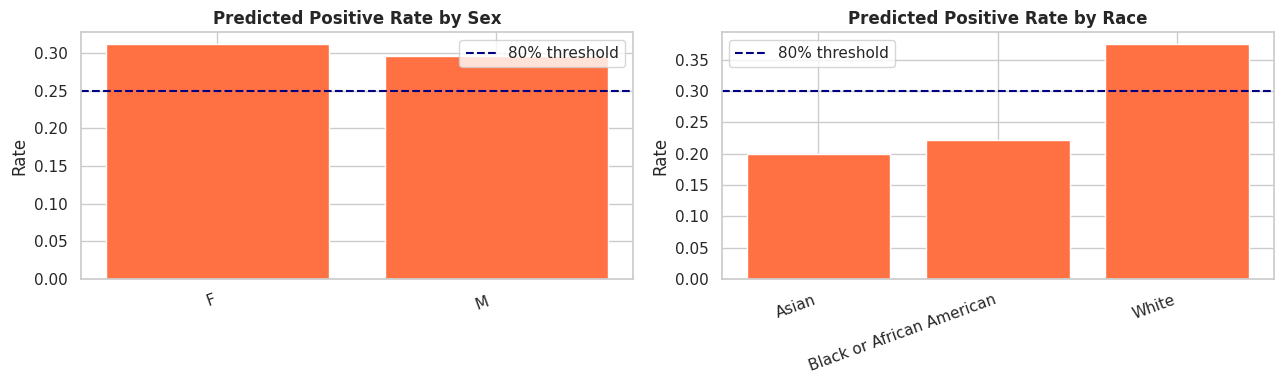

In [ ]:
# Visualise predicted positive rate across race groups
race_table_reset = fairness_table(df_fairness_test, 'RaceDesc').reset_index()
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, table, title in zip(
    axes,
    [sex_table.reset_index(), race_table_reset],
    ['Predicted Positive Rate by Sex', 'Predicted Positive Rate by Race']
):
    ax.bar(table['Group'], table['Predicted positive rate'], color='#FF7043', edgecolor='white')
    ax.axhline(0.8 * table['Predicted positive rate'].max(), color='navy', linestyle='--',
               label='80% threshold')
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Rate')
    ax.legend()
    plt.setp(ax.get_xticklabels(), rotation=20, ha='right')

plt.tight_layout()
plt.show()

---
## Section 9 — Risk Report for Active Employees

In [ ]:
# Score ALL active employees (not just test set)
active_mask = df_raw['EmploymentStatus'] == 'Active'
active_indices = df_raw[active_mask].index
# Only keep indices that survived our filtering pipeline
active_indices = [i for i in active_indices if i in df.index]

X_active = df.loc[active_indices, FEATURE_COLS].fillna(df[FEATURE_COLS].median(numeric_only=True))

if best_name == 'Logistic Regression':
    X_active_input = scaler.transform(X_active)
else:
    X_active_input = X_active

risk_scores = best_model.predict_proba(X_active_input)[:, 1]

print(f'Active employees scored: {len(risk_scores)}')
print(f'Mean risk score: {risk_scores.mean():.3f}')

Active employees scored: 207
Mean risk score: 0.036


In [ ]:
# SHAP for active employees
if best_name == 'Logistic Regression':
    shap_active = explainer.shap_values(X_active_input)
    X_active_shap = pd.DataFrame(X_active_input, columns=FEATURE_COLS, index=active_indices)
else:
    shap_active = explainer.shap_values(X_active)
    if isinstance(shap_active, list):
        shap_active = shap_active[1]
    X_active_shap = X_active.copy()

shap_active_df = pd.DataFrame(shap_active, columns=FEATURE_COLS, index=active_indices)
print('Active SHAP computed. Shape:', shap_active_df.shape)

Active SHAP computed. Shape: (207, 25)


In [ ]:
# Retention action mapping
ACTION_MAP = {
    'EmpSatisfaction':           'HR check-in / satisfaction interview',
    'EngagementSurvey':          'Manager discussion / project reassignment',
    'engagement_x_satisfaction': 'HR check-in / engagement improvement plan',
    'has_transfer_request':      'Internal mobility conversation',
    'salary_vs_dept_mean':       'Compensation review',
    'feedback_has_growth':       'Development plan / promotion track',
    'feedback_has_workload':     'Workload audit / staffing review',
    'feedback_has_management':   'Manager coaching or team reassignment',
    'feedback_has_compensation': 'Compensation and benefits review',
    'feedback_has_departure_intent': 'Urgent retention conversation with HR',
    'Absences':                  'Wellbeing or flexibility discussion',
    'DaysLateLast30':            'Wellbeing or flexibility discussion',
    'tenure_years':              'Career development milestone review',
    'days_since_review':         'Schedule overdue performance review',
    'SpecialProjectsCount':      'Assign meaningful stretch projects',
}

def top_shap_actions(row_shap, n=3):
    """Return top n positive SHAP features (risk drivers) and their actions."""
    sorted_feats = row_shap.sort_values(ascending=False)
    top_feats = sorted_feats[sorted_feats > 0].head(n)
    reasons = top_feats.index.tolist()
    # Pad if fewer than n
    while len(reasons) < n:
        reasons.append('')
    actions = [ACTION_MAP.get(r, 'Monitor and follow-up') for r in reasons if r]
    return reasons[0], reasons[1] if len(reasons) > 1 else '', reasons[2] if len(reasons) > 2 else '', \
           ' | '.join(actions) if actions else 'No specific action'

# Build risk report
report_rows = []
for i, (idx, shap_row) in enumerate(shap_active_df.iterrows()):
    r1, r2, r3, action = top_shap_actions(shap_row)
    risk_score = risk_scores[i]
    risk_level = 'High' if risk_score > 0.6 else ('Medium' if risk_score > 0.3 else 'Low')
    report_rows.append({
        'anonymized_id': f'EMP_{i+1:04d}',
        'Department': df.loc[idx, 'Department'] if 'Department' in df.columns else '',
        'Position': df.loc[idx, 'Position'] if 'Position' in df.columns else '',
        'risk_score': round(risk_score, 4),
        'risk_level': risk_level,
        'top_reason_1': r1,
        'top_reason_2': r2,
        'top_reason_3': r3,
        'recommended_action': action,
    })

risk_report = pd.DataFrame(report_rows)
print(f'Risk report generated: {len(risk_report)} active employees')
print(risk_report['risk_level'].value_counts())

Risk report generated: 207 active employees
risk_level
Low       203
Medium      4
Name: count, dtype: int64


In [ ]:
# Preview top 10 highest-risk employees
risk_report.sort_values('risk_score', ascending=False).head(10)

,anonymized_id,Department,Position,risk_score,risk_level,top_reason_1,top_reason_2,top_reason_3,recommended_action
5,EMP_0006,Production,Production Technician I,0.5847,Medium,feedback_has_growth,tenure_years,feedback_sentiment,Development plan / promotion track | Career development milestone review | M...
48,EMP_0049,Software Engineering,Software Engineer,0.4420,Medium,feedback_has_growth,Position_enc,RecruitmentSource_enc,Development plan / promotion track | Monitor and follow-up | Monitor and fol...
78,EMP_0079,IT/IS,IT Support,0.3513,Medium,feedback_has_growth,Absences,feedback_sentiment,Development plan / promotion track | Wellbeing or flexibility discussion | M...
83,EMP_0084,Production,Production Technician I,0.3014,Medium,feedback_has_growth,feedback_sentiment,has_transfer_request,Development plan / promotion track | Monitor and follow-up | Internal mobili...
110,EMP_0111,Sales,Area Sales Manager,0.2954,Low,feedback_has_growth,tenure_years,Absences,Development plan / promotion track | Career development milestone review | W...
30,EMP_0031,Production,Production Technician I,0.2194,Low,feedback_has_growth,feedback_sentiment,has_transfer_request,Development plan / promotion track | Monitor and follow-up | Internal mobili...
159,EMP_0160,Production,Production Technician I,0.1613,Low,feedback_has_growth,feedback_sentiment,has_transfer_request,Development plan / promotion track | Monitor and follow-up | Internal mobili...
124,EMP_0125,Production,Production Technician II,0.1444,Low,feedback_has_growth,feedback_sentiment,has_transfer_request,Development plan / promotion track | Monitor and follow-up | Internal mobili...
66,EMP_0067,Production,Production Technician I,0.1390,Low,feedback_has_growth,PerformanceScore_enc,feedback_sentiment,Development plan / promotion track | Monitor and follow-up | Monitor and fol...
10,EMP_0011,Production,Production Technician I,0.1380,Low,CitizenDesc_enc,tenure_years,engagement_x_satisfaction,Monitor and follow-up | Career development milestone review | HR check-in / ...


Exported: risk_report_active.csv


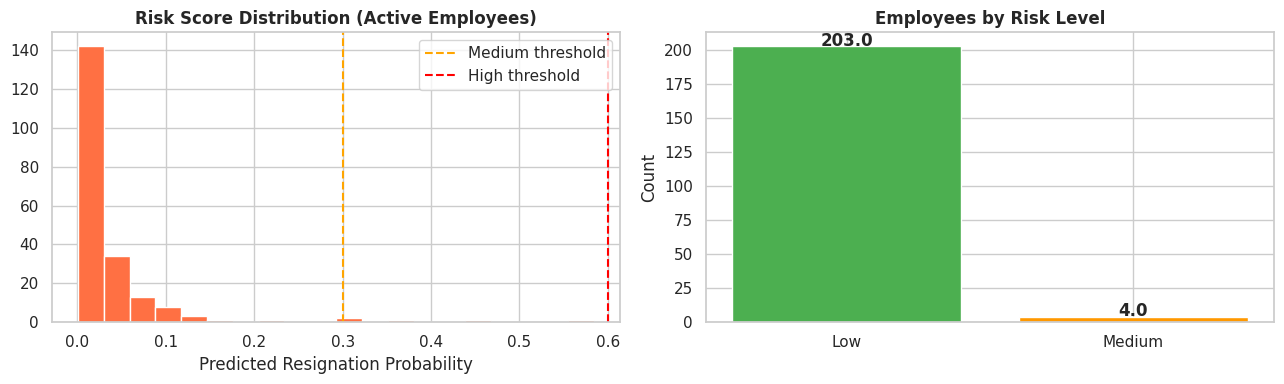

In [ ]:
# Export — no PII, no raw text
risk_report.sort_values('risk_score', ascending=False).to_csv('risk_report_active.csv', index=False)
print('Exported: risk_report_active.csv')

# Risk distribution plot
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(risk_scores, bins=20, color='#FF7043', edgecolor='white')
axes[0].axvline(0.3, color='orange', linestyle='--', label='Medium threshold')
axes[0].axvline(0.6, color='red',    linestyle='--', label='High threshold')
axes[0].set_title('Risk Score Distribution (Active Employees)', fontweight='bold')
axes[0].set_xlabel('Predicted Resignation Probability')
axes[0].legend()

level_counts = risk_report['risk_level'].value_counts().reindex(['Low', 'Medium', 'High'])
axes[1].bar(level_counts.index, level_counts.values,
            color=['#4CAF50', '#FF9800', '#F44336'], edgecolor='white')
axes[1].set_title('Employees by Risk Level', fontweight='bold')
axes[1].set_ylabel('Count')
for i, v in enumerate(level_counts.values):
    axes[1].text(i, v + 0.3, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

---
## Section 10 — Ethics & Cyber Safeguards Summary

### Privacy & Data Protection

| Category | Fields | Action |
|---|---|---|
| Direct identifiers | `Employee_Name`, `EmpID`, `ManagerName`, `ManagerID` | **Removed** before any modeling |
| Outcome leakage | `Termd`, `DateofTermination`, `TermReason`, `EmploymentStatus`, `EmpStatusID` | **Removed** to avoid data leakage |
| Quasi-identifiers | `DOB`, `DateofHire`, `Zip`, `State` | **Transformed** (age, tenure) or dropped |
| Raw text | `Internal_Transfer_Request`, `Feedback_RH` | **Converted** to numeric signals only; raw text dropped from model |
| Risk report output | All fields | **Anonymized IDs** only — no names, no raw text, no zip codes |

### Ethical AI — Non-Discrimination

| Rule | Implementation |
|---|---|
| Do not use protected attributes as features | `Sex`, `RaceDesc`, `HispanicLatino` excluded from model inputs |
| Fairness audit conducted | AUC and predicted positive rate compared across Sex and RaceDesc groups |
| Disparate impact check | 80% rule applied — flagged if any group < 80% of highest group's rate |
| Model understandability | SHAP values provided globally and per-employee; HR-readable action mapping |

### Frugality

- No external API calls or paid services used
- No large language model as the core product
- NLP layer uses lightweight VADER (rule-based) and keyword matching
- Models are standard sklearn/XGBoost — runnable on a laptop CPU in seconds
- Hyperparameter search limited to small grid to avoid unnecessary compute

### Explainability

- **Global**: SHAP summary and bar plots show which features drive risk across all employees
- **Local**: SHAP waterfall plots show why a specific employee received a high/low score
- **Actionable**: Each top SHAP driver is mapped to a concrete HR retention action
- **No black box output**: HR receives a reason + action for every flagged employee, not just a score

In [ ]:
# Download the risk report to your local machine (Colab only)
from google.colab import files
files.download('risk_report_active.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
## Section 11 — Individual Employee Risk Lookup

Enter an anonymized ID from the risk report table above (e.g. `EMP_0001`) to get a full breakdown:
- risk score and level
- the specific factors driving that employee's risk (with their actual values vs. the average)
- concrete HR actions to improve their situation

  EMPLOYEE RISK PROFILE  —  EMP_0006
  Department  : Production       
  Position    : Production Technician I
  Risk Score  : 58.5%
  Risk Level  : 🟡  MEDIUM

──────────────────────────────────────────────────────────────
  TOP RISK DRIVERS  (factors pushing this employee toward leaving)
──────────────────────────────────────────────────────────────
  1. Feedback mentions career/growth concerns
     Employee: 1.00  |  Average: 0.05  (▲ above avg)
     SHAP contribution: +2.0195

  2. Tenure (years)
     Employee: 16.69  |  Average: 12.55  (▲ above avg)
     SHAP contribution: +0.9001

  3. Overall feedback sentiment (VADER)
     Employee: 0.84  |  Average: 0.26  (▲ above avg)
     SHAP contribution: +0.2720

  4. RecruitmentSource_enc
     Employee: 1.00  |  Average: 3.76  (▼ below avg)
     SHAP contribution: +0.2566

  5. Has submitted a transfer request
     Employee: 0.00  |  Average: 0.35  (▼ below avg)
     SHAP contribution: +0.2235

────────────────────────────────────────────

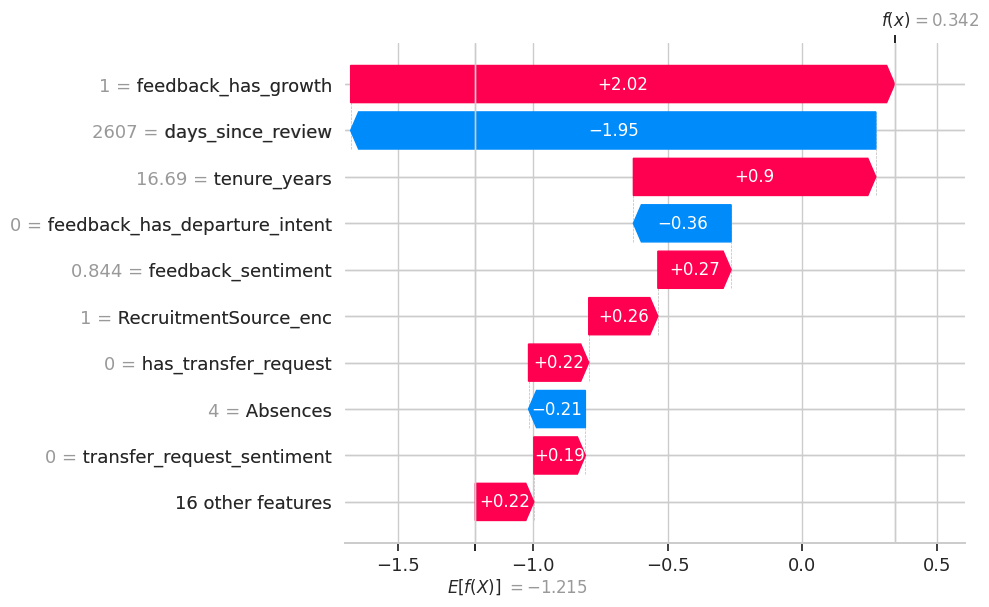

In [ ]:
# ── CHANGE THIS to any ID from the risk report table above ───────────────────
EMPLOYEE_ID = 'EMP_0006'
# ─────────────────────────────────────────────────────────────────────────────

FEATURE_LABELS = {
    'EmpSatisfaction':             'Employee satisfaction score (1–5)',
    'EngagementSurvey':            'Engagement survey score (0–5)',
    'engagement_x_satisfaction':   'Engagement × satisfaction composite',
    'has_transfer_request':        'Has submitted a transfer request',
    'transfer_request_sentiment':  'Sentiment of transfer request',
    'feedback_sentiment':          'Overall feedback sentiment (VADER)',
    'salary_vs_dept_mean':         'Salary vs. department average (ratio)',
    'feedback_has_growth':         'Feedback mentions career/growth concerns',
    'feedback_has_workload':       'Feedback mentions workload or stress',
    'feedback_has_management':     'Feedback mentions management issues',
    'feedback_has_compensation':   'Feedback mentions pay concerns',
    'feedback_has_departure_intent': 'Feedback signals departure intent',
    'Absences':                    'Number of absences',
    'DaysLateLast30':              'Days late in last 30 days',
    'tenure_years':                'Tenure (years)',
    'days_since_review':           'Days since last performance review',
    'SpecialProjectsCount':        'Number of special projects',
    'Salary':                      'Annual salary',
    'age':                         'Age',
}

RISK_EMOJI = {'High': '🔴', 'Medium': '🟡', 'Low': '🟢'}

# ── Lookup ────────────────────────────────────────────────────────────────────
match = risk_report[risk_report['anonymized_id'] == EMPLOYEE_ID]
if match.empty:
    print(f'Employee "{EMPLOYEE_ID}" not found.')
    print('Valid IDs:', risk_report['anonymized_id'].tolist()[:10], '...')
else:
    row      = match.iloc[0]
    pos      = match.index[0]          # positional index in risk_report / shap_active_df
    shap_row = shap_active_df.iloc[pos]
    feat_row = X_active.iloc[pos]
    col_means = X_active.mean()

    badge = RISK_EMOJI.get(row['risk_level'], '⚪')

    # ── Header ────────────────────────────────────────────────────────────────
    print('=' * 62)
    print(f'  EMPLOYEE RISK PROFILE  —  {EMPLOYEE_ID}')
    print('=' * 62)
    print(f"  Department  : {row['Department']}")
    print(f"  Position    : {row['Position']}")
    print(f"  Risk Score  : {row['risk_score']:.1%}")
    print(f"  Risk Level  : {badge}  {row['risk_level'].upper()}")
    print()

    # ── Top risk drivers ─────────────────────────────────────────────────────
    drivers = shap_row[shap_row > 0].sort_values(ascending=False).head(5)
    print('─' * 62)
    print('  TOP RISK DRIVERS  (factors pushing this employee toward leaving)')
    print('─' * 62)
    if drivers.empty:
        print('  No significant risk drivers found — this employee is below baseline risk.')
    else:
        for i, (feat, shap_val) in enumerate(drivers.items(), 1):
            label     = FEATURE_LABELS.get(feat, feat)
            emp_val   = feat_row[feat]
            avg_val   = col_means[feat]
            direction = '▲ above avg' if emp_val > avg_val else '▼ below avg'
            print(f'  {i}. {label}')
            print(f'     Employee: {emp_val:.2f}  |  Average: {avg_val:.2f}  ({direction})')
            print(f'     SHAP contribution: +{shap_val:.4f}')
            print()

    # ── What HR can improve ───────────────────────────────────────────────────
    print('─' * 62)
    print('  RECOMMENDED HR ACTIONS')
    print('─' * 62)
    actions = [a.strip() for a in row['recommended_action'].split('|') if a.strip()]
    for i, action in enumerate(actions, 1):
        print(f'  {i}. {action}')
    print()
    print('=' * 62)

    # ── SHAP waterfall ────────────────────────────────────────────────────────
    print('\nSHAP waterfall — what drives this employee\'s risk score:')
    base_val = explainer.expected_value
    if isinstance(base_val, (list, np.ndarray)):
        base_val = float(np.array(base_val).flat[1])

    shap.waterfall_plot(
        shap.Explanation(
            values=shap_row.values,
            base_values=base_val,
            data=feat_row.values,
            feature_names=FEATURE_COLS,

        ),
        max_display=10,
        show=True,
    )